# 01 · Circuits, entanglement, and Qiskit primitives

**Question:** How do gate operations become a quantum state, and how do sampling
and expectation-value calculations describe different aspects of that state?

This notebook organizes the circuit examples from my guided crash-course practice.
It covers basic gates, Bell/GHZ states, parameter binding, `StatevectorSampler`,
`StatevectorEstimator`, and Pauli Hamiltonians. All calculations run locally on
ideal simulators. Use **Restart Kernel → Run All** to reproduce the outputs.

Install the project first using the [README](../README.md).

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import qiskit
from IPython.display import display
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.primitives import StatevectorSampler, StatevectorEstimator
from qiskit.quantum_info import Statevector, SparsePauliOp, partial_trace
from qiskit.visualization import plot_histogram

print('Qiskit version:', qiskit.__version__)

Qiskit version: 2.5.2


## 1. Build a circuit and identify the operations

`QuantumCircuit(n)` starts $n$ qubits in $|0\ldots0\rangle$.
`x`, `y`, and `z` are Pauli gates; `h` is a Hadamard gate; `rx`, `ry`, and `rz`
rotate a qubit by the supplied angle. `cx(control, target)` flips the target
conditioned on the control being $|1\rangle$. `cz` applies a conditional phase.

The example below is a gate reference, not an algorithm. Building a new circuit
for each experiment avoids accidentally carrying gates over from earlier cells.

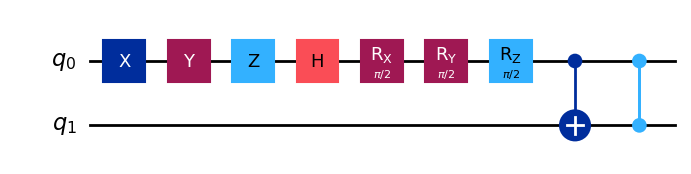

In [2]:
gate_reference = QuantumCircuit(2)
gate_reference.x(0)
gate_reference.y(0)
gate_reference.z(0)
gate_reference.h(0)
gate_reference.rx(np.pi / 2, 0)
gate_reference.ry(np.pi / 2, 0)
gate_reference.rz(np.pi / 2, 0)
gate_reference.cx(0, 1)
gate_reference.cz(0, 1)
display(gate_reference.draw('mpl', fold=45))
plt.close('all')  # Prevent a second automatic inline display.

## 2. Prepare and inspect a Bell state

Applying $H$ to qubit 0, followed by CX from qubit 0 to qubit 1, prepares
$|\Phi^+\rangle=(|00\rangle+|11\rangle)/\sqrt{2}$.
Keep an unmeasured circuit for statevector calculations and a separate measured
copy for sampling.

**Bit ordering:** Qiskit displays two-qubit strings as $q_1q_0$.
The statevector entries are ordered $|00\rangle,|01\rangle,|10\rangle,|11\rangle$.
Thus applying X to qubit 0 of $|00\rangle$ produces $|01\rangle$.

Amplitudes: [0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]
Exact probabilities: {np.str_('00'): np.float64(0.4999999999999999), np.str_('11'): np.float64(0.4999999999999999)}


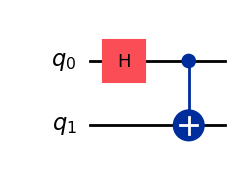

In [3]:
bell = QuantumCircuit(2, name='Bell')
bell.h(0)
bell.cx(0, 1)
display(bell.draw('mpl'))
plt.close('all')  # Prevent a second automatic inline display.

bell_state = Statevector.from_instruction(bell)
print('Amplitudes:', bell_state.data)
print('Exact probabilities:', bell_state.probabilities_dict())
np.testing.assert_allclose(bell_state.probabilities(), [0.5, 0, 0, 0.5], atol=1e-12)

A 50/50 histogram alone does not prove entanglement: an incoherent mixture of
$|00\rangle$ and $|11\rangle$ has the same probabilities. Here the simulated pure
state has coherent amplitudes, $\langle XX\rangle=1$, and each individual qubit has
reduced density matrix $I/2$. These checks reveal more than the histogram.

In [4]:
print('<XX> =', float(bell_state.expectation_value(SparsePauliOp('XX')).real))
reduced_q0 = partial_trace(bell_state, [1])
print('Reduced density matrix of qubit 0:\n', reduced_q0.data)
np.testing.assert_allclose(reduced_q0.data, np.eye(2) / 2, atol=1e-12)

<XX> = 0.9999999999999998
Reduced density matrix of qubit 0:
 [[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]


## 3. Sample measurement outcomes

A shot is one sampled measurement outcome. `measure_all()` creates a classical
register named `meas`, so counts are retrieved through `result[0].data.meas`.
The seed fixes the random sampling in the tested environment. A finite sample
need not contain exactly 500 occurrences of each Bell-state outcome.

Bell counts: {'11': 497, '00': 503}


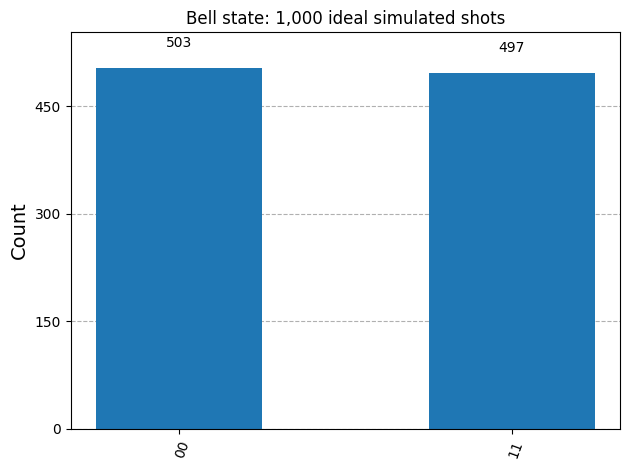

In [5]:
measured_bell = bell.copy()
measured_bell.measure_all()
sampler = StatevectorSampler(seed=42)
result = sampler.run([measured_bell], shots=1000).result()
bell_counts = result[0].data.meas.get_counts()
print('Bell counts:', bell_counts)
assert sum(bell_counts.values()) == 1000
assert set(bell_counts) <= {'00', '11'}
display(plot_histogram(bell_counts, title='Bell state: 1,000 ideal simulated shots'))
plt.close('all')  # Prevent a second automatic inline display.

## 4. Extend the construction to a three-qubit GHZ state

A second CX correlates the third qubit with the first two. The expected state is
$(|000\rangle+|111\rangle)/\sqrt{2}$, giving only `000` and `111` outcomes here.

Exact GHZ probabilities: {np.str_('000'): np.float64(0.4999999999999999), np.str_('111'): np.float64(0.4999999999999999)}
GHZ counts: {'111': 1016, '000': 984}


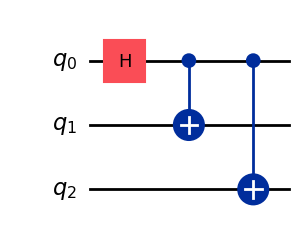

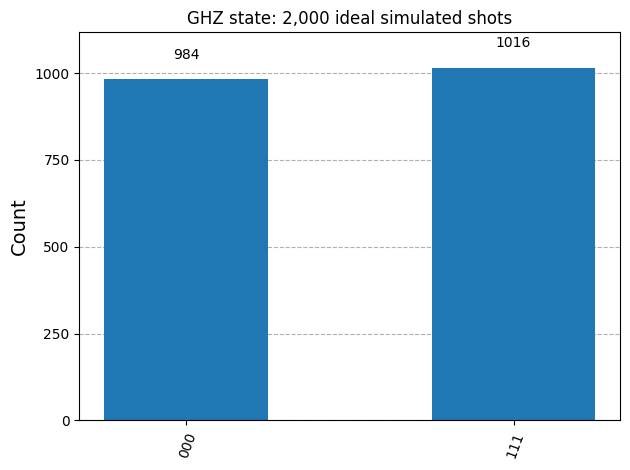

In [6]:
ghz = QuantumCircuit(3, name='GHZ')
ghz.h(0)
ghz.cx(0, 1)
ghz.cx(0, 2)
display(ghz.draw('mpl'))
plt.close('all')  # Prevent a second automatic inline display.

ghz_state = Statevector.from_instruction(ghz)
print('Exact GHZ probabilities:', ghz_state.probabilities_dict())
measured_ghz = ghz.copy()
measured_ghz.measure_all()
ghz_result = StatevectorSampler(seed=43).run([measured_ghz], shots=2000).result()
ghz_counts = ghz_result[0].data.meas.get_counts()
print('GHZ counts:', ghz_counts)
assert set(ghz_counts) <= {'000', '111'}
display(plot_histogram(ghz_counts, title='GHZ state: 2,000 ideal simulated shots'))
plt.close('all')  # Prevent a second automatic inline display.

## 5. Bind a circuit parameter and sweep an angle

$R_y(\theta)|0\rangle=\cos(\theta/2)|0\rangle+\sin(\theta/2)|1\rangle$,
so $P(1)=\sin^2(\theta/2)$. `assign_parameters` returns a bound copy by default;
it leaves the adjustable template available for the next angle.

theta (rad)   P(0)       P(1)
    0.0000   1.000000   0.000000
    0.7854   0.853553   0.146447
    1.5708   0.500000   0.500000
    2.3562   0.146447   0.853553
    3.1416   0.000000   1.000000


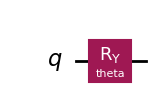

In [7]:
theta = Parameter('theta')
rotation = QuantumCircuit(1)
rotation.ry(theta, 0)
display(rotation.draw('mpl'))
plt.close('all')  # Prevent a second automatic inline display.

angles = np.linspace(0, np.pi, 5)
print('theta (rad)   P(0)       P(1)')
for angle in angles:
    bound = rotation.assign_parameters({theta: angle})
    probabilities = Statevector.from_instruction(bound).probabilities()
    np.testing.assert_allclose(probabilities[1], np.sin(angle / 2) ** 2, atol=1e-12)
    print(f'{angle:10.4f}   {probabilities[0]:.6f}   {probabilities[1]:.6f}')

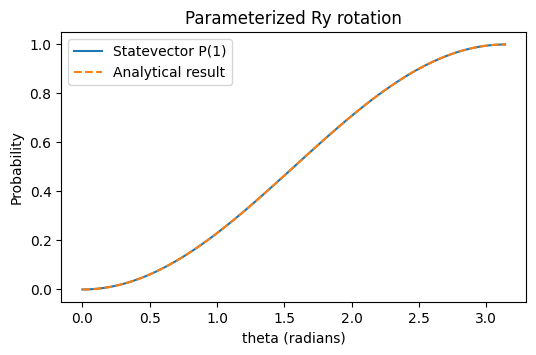

In [8]:
dense_angles = np.linspace(0, np.pi, 101)
simulated_p1 = [
    Statevector.from_instruction(rotation.assign_parameters({theta: angle})).probabilities()[1]
    for angle in dense_angles
]
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(dense_angles, simulated_p1, label='Statevector P(1)')
ax.plot(dense_angles, np.sin(dense_angles / 2) ** 2, '--', label='Analytical result')
ax.set(xlabel='theta (radians)', ylabel='Probability', title='Parameterized Ry rotation')
ax.legend()
plt.show()

## 6. Calculate an expectation value with Estimator

Sampler returns measurement outcomes. Estimator returns an expectation value
$\langle O\rangle=\langle\psi|O|\psi\rangle$ for a specified observable.
For $|+\rangle=H|0\rangle$, $\langle Z\rangle=0$ and $\langle X\rangle=1$.
This statevector estimator uses exact expectations for these unitary circuits;
it is not modeling finite-shot expectation estimation.

In [9]:
plus = QuantumCircuit(1)
plus.h(0)
estimator = StatevectorEstimator()
z_value = float(estimator.run([(plus, SparsePauliOp('Z'))]).result()[0].data.evs)
x_value = float(estimator.run([(plus, SparsePauliOp('X'))]).result()[0].data.evs)
print('<Z> =', z_value)
print('<X> =', x_value)
np.testing.assert_allclose([z_value, x_value], [0, 1], atol=1e-12)

<Z> = 0.0
<X> = 0.9999999999999998


## 7. Represent a spin Hamiltonian as a sum of Pauli operators

The crash-course example used $H=JZ_1Z_0+hX_1+hX_0$ with $J=1$ and $h=-0.5$.
In Qiskit's Pauli strings, `XI` acts on qubit 1 and `IX` on qubit 0.
For the Bell state above, $\langle ZZ\rangle=1$ and both single-qubit
X expectations vanish, so the expected energy is $1$.

In [10]:
ising_hamiltonian = SparsePauliOp.from_list([
    ('ZZ', 1.0),
    ('XI', -0.5),
    ('IX', -0.5),
])
energy = float(estimator.run([(bell, ising_hamiltonian)]).result()[0].data.evs)
print(ising_hamiltonian)
print('Bell-state energy:', energy)
np.testing.assert_allclose(energy, 1.0, atol=1e-12)

SparsePauliOp(['ZZ', 'XI', 'IX'],
              coeffs=[ 1. +0.j, -0.5+0.j, -0.5+0.j])
Bell-state energy: 0.9999999999999998


## What this notebook demonstrates

I can build and inspect small circuits, bind parameters, distinguish sampled
outcomes from expectation values, and check results against quantum-mechanical
predictions. Next, [Notebook 02](02_vqe_ground_state.ipynb) uses a parameterized
state in a classical optimization loop.

**References:** [Qiskit bit ordering](https://quantum.cloud.ibm.com/docs/en/guides/bit-ordering),
[StatevectorSampler](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.primitives.StatevectorSampler),
[StatevectorEstimator](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.primitives.StatevectorEstimator).